In [1]:
import zarr
o = zarr.open_group('/tmp/turbospectrum_nlte_local_test/ml_grid.zarr', mode='r')

In [2]:
o.tree()

/
├── a (8,) object
├── c (8,) object
├── calculation_mode (8,) object
├── feh (8,) float64
├── grid_version (8,) object
├── lam_max (8,) float64
├── lam_min (8,) float64
├── lam_step (8,) float64
├── logg (8,) float64
├── mode (8,) object
├── n (8,) object
├── nlte_ascii_abundance_column (8,) object
├── nlte_ascii_abundance_scale (8,) object
├── nlte_ascii_departure_dir (8,) object
├── nlte_ascii_departure_species (8,) object
├── nlte_ascii_match (8,) object
├── o (8,) object
├── output_mode (8,) object
├── r (8,) object
├── s (8,) object
├── t_value (8,) object
├── teff (8,) int64
└── turbvel (8,) object

In [1]:
import sys, os
sys.path.append(os.path.join('.'))

In [2]:
from scripts.read_nlte_grid import read_binary_grid, write_departures_for_ts, plot_departure_coefficients

# Example: read first grid record (byte pointer 1001 = right after 1000-byte header).
# For other models, set pointer= from the NLTE auxiliary model list file.

In [3]:
ndep, nk, depart, tau, atmosStr = read_binary_grid(
    "/Users/mjablons/Documents/Turbospectrum_NLTE/DATA/DEP/NLTEgrid4TS_Fe_MARCS_May-07-2021.bin"
)

NLTE departures: 100%|██████████| 607/607 [00:00<00:00, 18876.59lvl/s]


In [7]:
depart.shape

(607, 56)

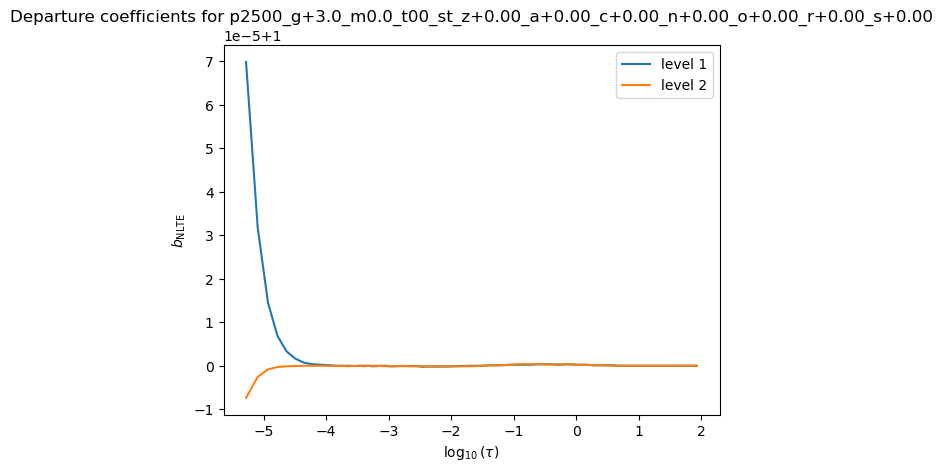

In [10]:
plot_departure_coefficients(depart, tau, atmosStr, levels_to_plot=[1, 2])

In [ ]:
write_departures_for_ts('/Users/mjablons/Documents/Turbospectrum_NLTE/DATA/DEP/NLTEgrid4TS_Fe_MARCS_May-07-2021.ascii',
                        tau, depart, abund)